# Node neighbourhood similarity compared to node encoding distance for various structural encodings

Compare various structural encodings on how they capture the similarity of the nodes in the graphs.

In [1]:
%reload_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

BASE_PATH = "../lpca_out/"
SIM_PATH = "../output/similarity_res/"
PROPERTIES_PATH = "../output/properties/"

plt.rcParams.update({'font.size': 16})

In [2]:
def plot_neighbourhood_distance_multiple(df_paths, title):
    for label, df_path in df_paths.items():
        df = pd.read_parquet(df_path)
        data = df.groupby("d")["sim"].agg(["mean", "std"])

        plt.errorbar(data.index, data["mean"], yerr=data["std"], fmt='-o', capsize=0.2, capthick=1, label=label)
    plt.xlabel("neighbourhood symmetric difference")
    plt.ylabel("average distance between \n distinct node encoding pairs")
    plt.title(title)
    plt.legend()
    plt.legend()
    plt.savefig("neighbourhood_similarity_plot.png")
    plt.show()

def plot_neighbourhood_similarity_multiple(df_paths, title):
    for label, df_path in df_paths.items():
        df = pd.read_parquet(df_path)
        # Stack all y_mean rows into a 2D array of shape (n_rows, 20)
        y_mean_arr = np.stack(df["sim_mean"].to_numpy())  # or df["y_mean"].values
        # Elementwise mean over rows → shape (20,)
        sim_mean = np.nanmean(y_mean_arr, axis=0)
        sim_std = np.nanstd(y_mean_arr, axis=0)

        plt.errorbar(df["d"][0], sim_mean, yerr=sim_std, fmt='-o', capsize=0.2, capthick=1, label=label)
    plt.xlabel("new similarity score")
    plt.ylabel("average distance between \n distinct node encoding pairs")
    plt.title(title)
    plt.legend()
    plt.legend()
    plt.savefig("neighbourhood_similarity_plot.png")
    plt.show()

def plot_neighbourhood_distance_single(df_paths, i, title):
    for label, df_path in df_paths.items():
        df = pd.read_parquet(df_path)
        data = df.iloc[i]

        plt.errorbar(range(data["d"].size), data["sim_mean"], yerr=data["sim_std"], fmt='-o', capsize=0.2, capthick=1, label=label)
    plt.xlabel("neighbourhood symmetric difference")
    plt.ylabel("average distance between \n distinct node encoding pairs")
    plt.title(title)
    plt.legend()
    plt.savefig("neighbourhood_similarity_plot.png")
    plt.show()

def plot_neighbourhood_similarity_single(df_paths, i, title):
    for label, df_path in df_paths.items():
        df = pd.read_parquet(df_path)
        data = df.iloc[i]

        plt.errorbar(data["d"], data["sim_mean"], yerr=data["sim_std"], fmt='-o', capsize=0.2, capthick=1, label=label)
    plt.xlabel("new similarity score")
    plt.ylabel("average distance between \n distinct node encoding pairs")
    plt.title(title)
    plt.legend()
    plt.savefig("neighbourhood_similarity_plot.png")
    plt.show()

def plot_error(df_paths):
    for label, df_path in df_paths.items():
        df = pd.read_parquet(df_path)
        error = df["error"]

        error_mean = error.mean()
        error_std = error.std()
        display(f"{label}: reconstruction error mean = {error_mean}, std = {error_std}")

        plt.hist(error, align="left", range=(0,1), edgecolor="black", linewidth=1)
        plt.title(f"Reconstruction Error hist for {label}")
        plt.xlabel("Error")
        plt.ylabel("number of node pairs")
        plt.show()

'Sim, ZINC, gamma=0.3: reconstruction error mean = 0.0012909944634884596, std = 0.018257418647408485'

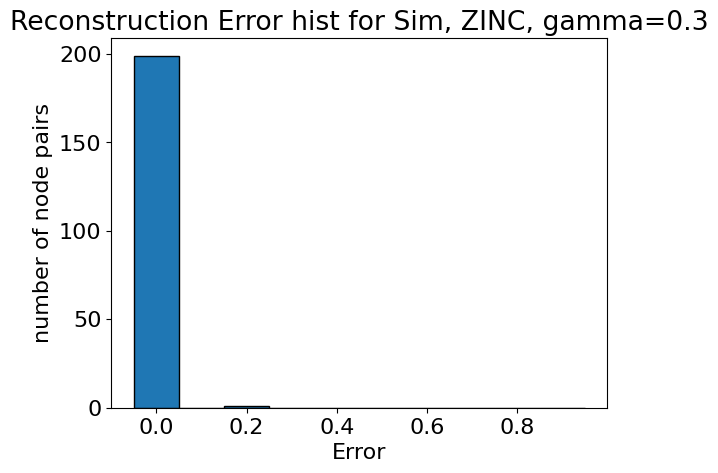

'Sim, ZINC, gamma=1.0: reconstruction error mean = 0.006768324412405491, std = 0.04429163783788681'

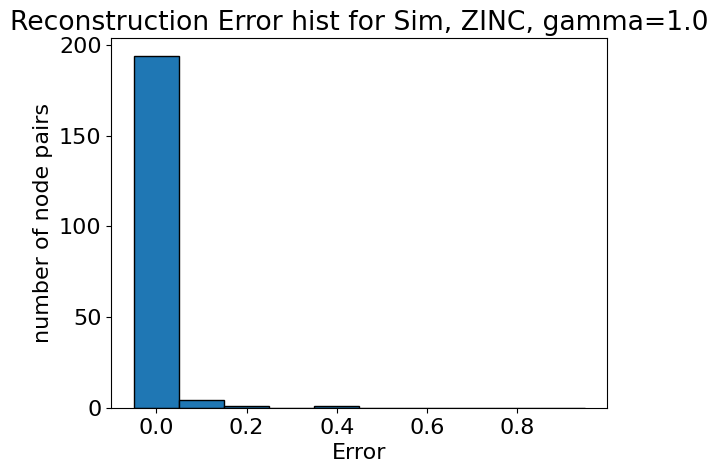

'Sim, Peptides, gamma=0.3: reconstruction error mean = 0.10254133492708206, std = 0.17350097000598907'

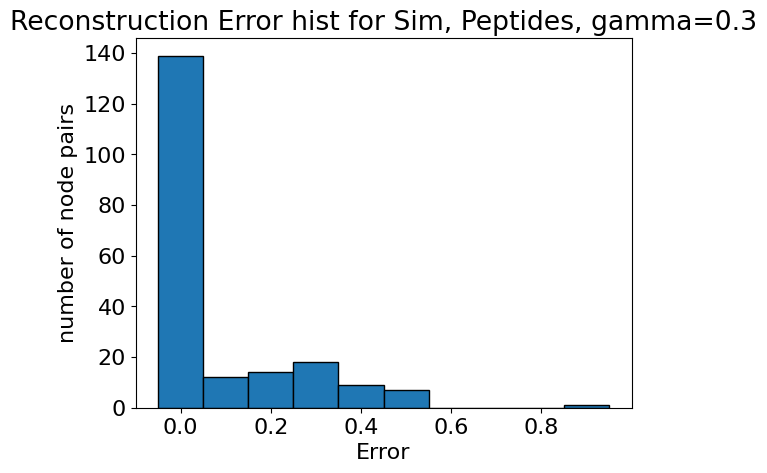

'Sim, Peptides, gamma=1.0: reconstruction error mean = 0.5501001477241516, std = 0.35706275701522827'

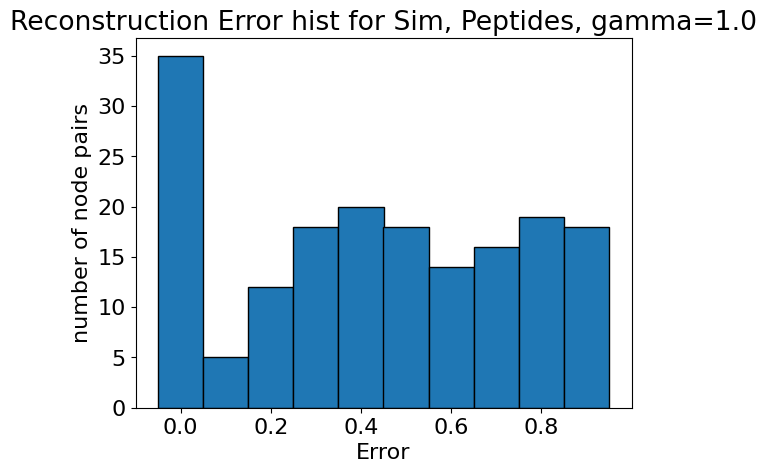

'Sim, CIFAR, gamma=0.3: reconstruction error mean = 0.0, std = 0.0'

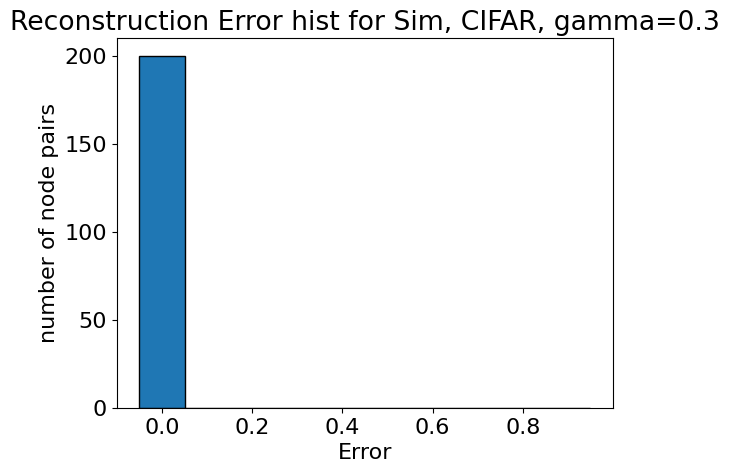

'Sim, CIFAR, gamma=1.0: reconstruction error mean = 0.11478252708911896, std = 0.07194830477237701'

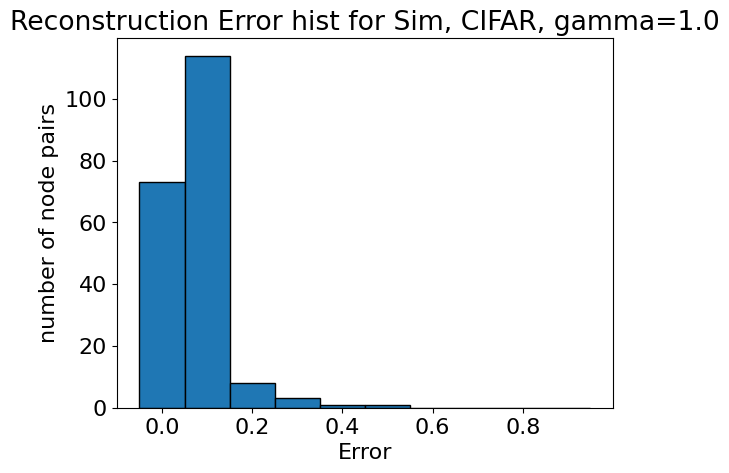

In [29]:
plot_error({f"Sim, ZINC, gamma={g}": BASE_PATH + f"lpca_with_sim_new_ZINC_methodSim_k8_b4_gamma{g}_s200.parquet" for g in [0.3, 1.0]})
plot_error({f"Sim, Peptides, gamma={g}": BASE_PATH + f"lpca_with_sim_new_Peptides_methodSim_k8_b4_gamma{g}_s200.parquet" for g in [0.3, 1.0]})
plot_error({f"Sim, CIFAR, gamma={g}": BASE_PATH + f"lpca_with_sim_new_CIFAR_methodSim_k12_b4_gamma{g}_s200.parquet" for g in [0.3, 1.0]})

In [30]:
plot_error({f"Dist, ZINC, gamma={g}": BASE_PATH + f"lpca_with_sim_new_ZINC_methodDist_k8_b4_gamma{g}_s200.parquet" for g in [0.0, 0.3, 1.0]})
plot_error({f"Dist, Peptides, gamma={g}": BASE_PATH + f"lpca_with_sim_new_Peptides_methodDist_k8_b4_gamma{g}_s200.parquet" for g in [0.0, 0.3, 1.0]})
plot_error({f"Dist, CIFAR, gamma={g}": BASE_PATH + f"lpca_with_sim_new_CIFAR_methodDist_k12_b4_gamma{g}_s200.parquet" for g in [0.0, 0.3, 1.0]})

FileNotFoundError: [Errno 2] No such file or directory: '../lpca_out/lpca_with_sim_new_ZINC_methodDist_k8_b4_gamma0.0_s200.parquet'

In [6]:
plot_neighbourhood_distance_multiple({r'$\gamma$' + f"={g}": SIM_PATH + f"similarity_lpca_with_sim_new_ZINC_methodDist_k8_b4_gamma{g}_s200.parquet" for g in [0.0, 0.3, 1.0]}, "ZINC LPCA-sim dim 16 encoding similarity")

FileNotFoundError: [Errno 2] No such file or directory: '../output/similarity_res/similarity_lpca_with_sim_new_ZINC_methodDist_k8_b4_gamma0.0_s200.parquet'

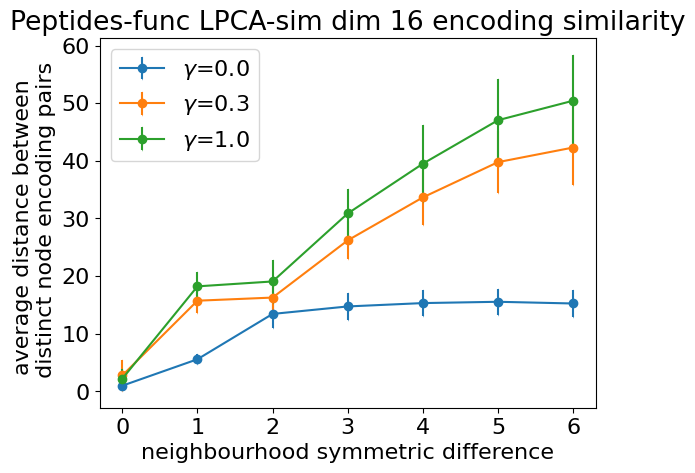

In [56]:
plot_neighbourhood_distance_multiple({r'$\gamma$' + f"={g}": SIM_PATH + f"similarity_lpca_with_sim_new_Peptides_methodDist_k8_b4_gamma{g}_s200.parquet" for g in [0.0, 0.3, 1.0]}, "Peptides-func LPCA-sim dim 16 encoding similarity")

In [10]:
plot_neighbourhood_distance_multiple({r'$\gamma$' + f"={g}": SIM_PATH + f"similarity_lpca_with_sim_new_CIFAR_methodDist_k12_b4_gamma{g}_s200.parquet" for g in [0.0, 0.3, 1.0]}, "CIFAR10 LPCA-sim dim 24 encoding similarity")

FileNotFoundError: [Errno 2] No such file or directory: '../output/similarity_res/similarity_lpca_with_sim_new_CIFAR_methodDist_k12_b4_gamma0.0_s200.parquet'

/tmp/ipykernel_23272/4215037740.py:21: RuntimeWarning: Mean of empty slice
  sim_mean = np.nanmean(y_mean_arr, axis=0)
/mnt/ntfs/SSD1/MSC/binary-matrix-factorization/.venv/lib64/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


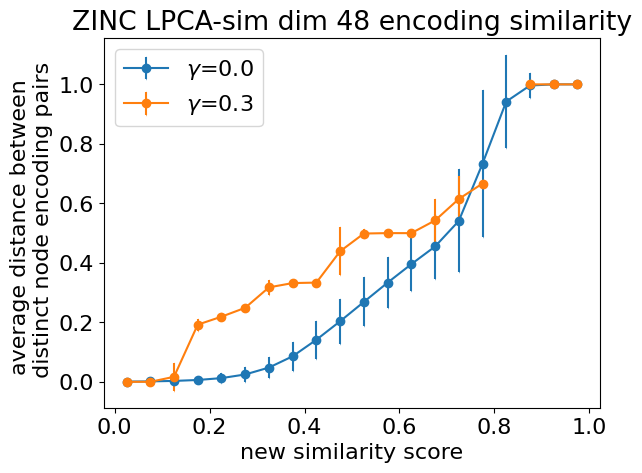

In [5]:
plot_neighbourhood_similarity_multiple({r'$\gamma$' + f"={g}": BASE_PATH + f"lpca_with_sim_new_ZINC_methodSim_k24_b4_gamma{g}_sNone.parquet" for g in [0.0, 0.3]}, "ZINC LPCA-sim dim 48 encoding similarity")

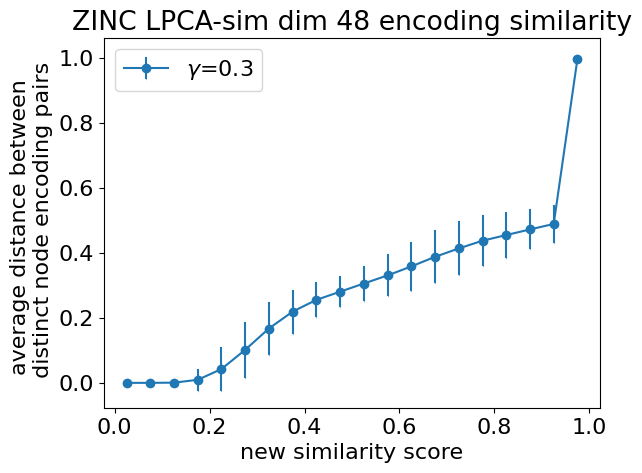

In [8]:
plot_neighbourhood_similarity_multiple({r'$\gamma$' + f"={g}": BASE_PATH + f"lpca_with_sim_new_ZINC_methodSim_k8_b4_gamma{g}_sNone.parquet" for g in [0.3]}, "ZINC LPCA-sim dim 48 encoding similarity")

/tmp/ipykernel_37338/1378544064.py:21: RuntimeWarning: Mean of empty slice
  sim_mean = np.nanmean(y_mean_arr, axis=0)
/mnt/ntfs/SSD1/MSC/binary-matrix-factorization/.venv/lib64/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


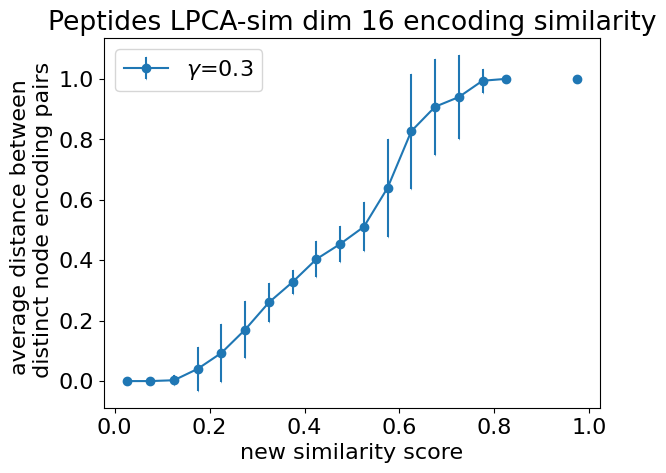

In [9]:
plot_neighbourhood_similarity_multiple({r'$\gamma$' + f"={g}": BASE_PATH + f"lpca_with_sim_new_Peptides_methodSim_k128_b4_gamma{g}_s200.parquet" for g in [0.3]}, "Peptides LPCA-sim dim 16 encoding similarity")

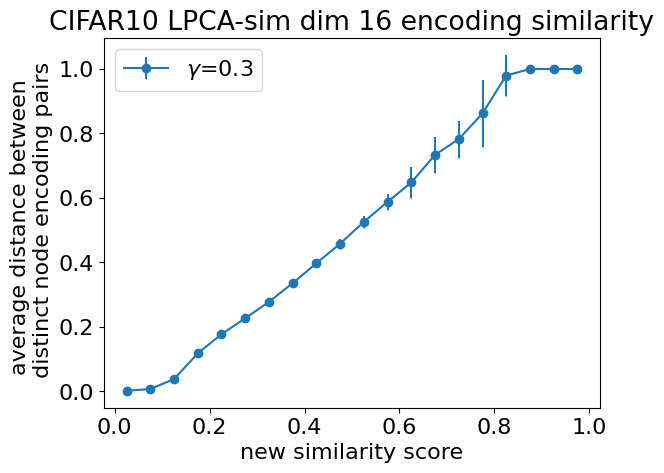

Connection closed unexpectedly!


In [10]:
plot_neighbourhood_similarity_multiple({r'$\gamma$' + f"={g}": BASE_PATH + f"lpca_with_sim_new_CIFAR_methodSim_k64_b4_gamma{g}_s200.parquet" for g in [0.3]}, "CIFAR10 LPCA-sim dim 16 encoding similarity")

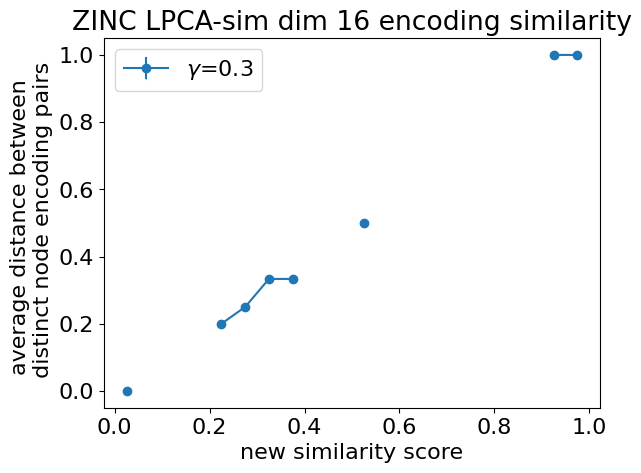

In [18]:
plot_neighbourhood_similarity_single({r'$\gamma$' + f"={g}": BASE_PATH + f"lpca_with_sim_new_ZINC_methodSim_k24_b4_gamma{g}_s200.parquet" for g in [0.3]}, 8, "ZINC LPCA-sim dim 16 encoding similarity")

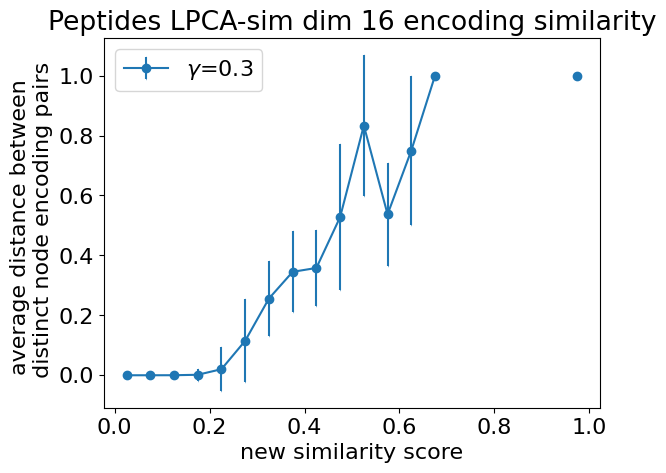

In [19]:
plot_neighbourhood_similarity_single({r'$\gamma$' + f"={g}": BASE_PATH + f"lpca_with_sim_new_Peptides_methodSim_k128_b4_gamma{g}_s200.parquet" for g in [0.3]}, 1, "Peptides LPCA-sim dim 16 encoding similarity")

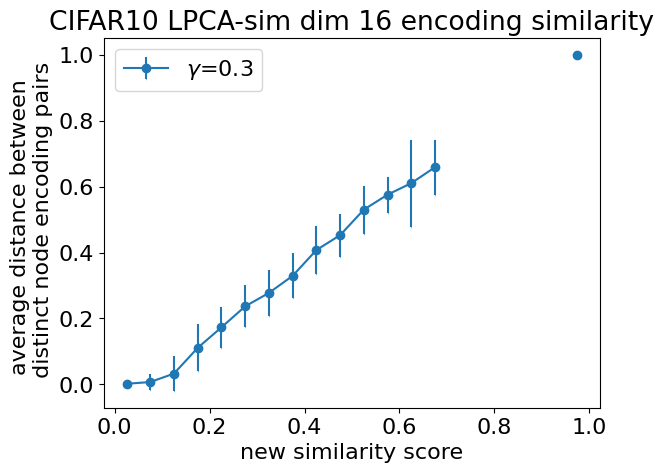

In [20]:
plot_neighbourhood_similarity_single({r'$\gamma$' + f"={g}": BASE_PATH + f"lpca_with_sim_new_CIFAR_methodSim_k64_b4_gamma{g}_s200.parquet" for g in [0.3]}, 1, "CIFAR10 LPCA-sim dim 16 encoding similarity")

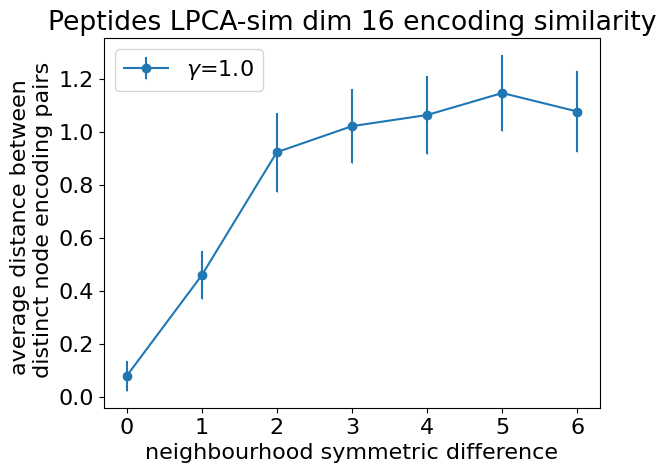

In [23]:
plot_neighbourhood_distance_single({r'$\gamma$' + f"={g}": BASE_PATH + f"lpca_with_sim_new_Peptides_methodDist_k8_b4_gamma{g}_s200.parquet" for g in [1.0]}, 0, "Peptides LPCA-sim dim 16 encoding similarity")

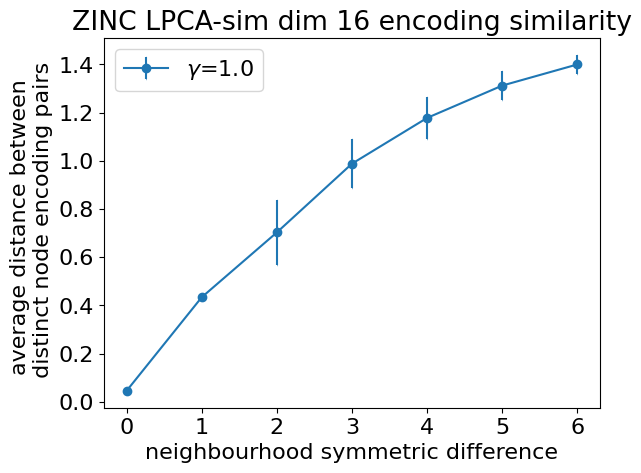

In [83]:
plot_neighbourhood_distance_single({r'$\gamma$' + f"={g}": BASE_PATH + f"lpca_with_sim_new_ZINC_methodDist_k8_b4_gamma{g}_s200.parquet" for g in [1.0]}, 10, "ZINC LPCA-sim dim 16 encoding similarity")

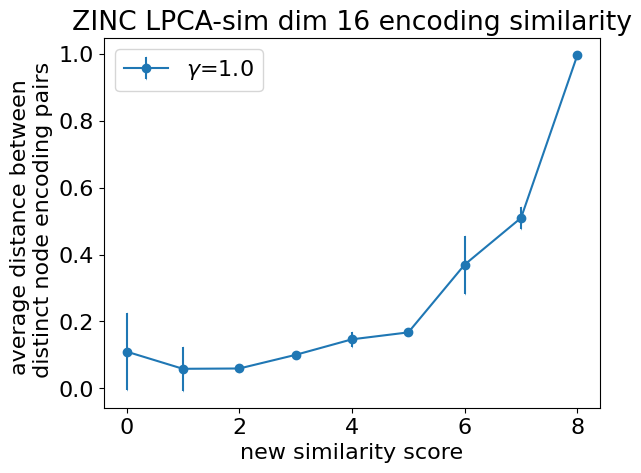

In [89]:
plot_neighbourhood_similarity_single({r'$\gamma$' + f"={g}": BASE_PATH + f"lpca_with_sim_new_ZINC_methodSim_k8_b4_gamma{g}_s200.parquet" for g in [1.0]}, 10, "ZINC LPCA-sim dim 16 encoding similarity")